<a href="https://colab.research.google.com/github/harshs-data/Deep-Learning/blob/main/early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [100]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

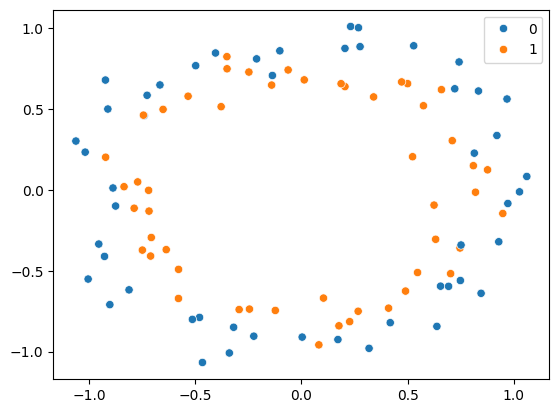

In [101]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [103]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [104]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [105]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

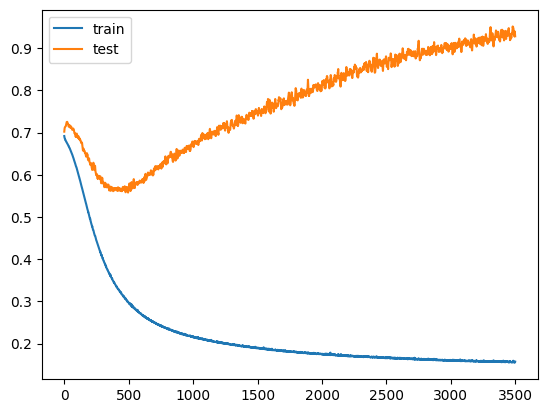

In [106]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 710us/step


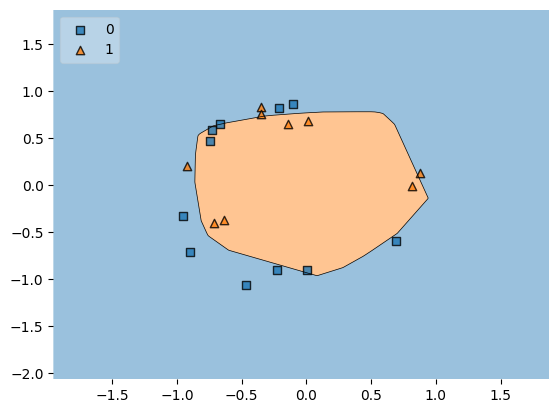

In [107]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

# Early Stopping

In [116]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [117]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [121]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=320,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [122]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500, callbacks=callback)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5250 - loss: 0.6895 - val_accuracy: 0.4000 - val_loss: 0.6981
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5375 - loss: 0.6887 - val_accuracy: 0.4000 - val_loss: 0.7003
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5375 - loss: 0.6875 - val_accuracy: 0.4000 - val_loss: 0.7016
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5500 - loss: 0.6868 - val_accuracy: 0.4000 - val_loss: 0.7029
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5625 - loss: 0.6858 - val_accuracy: 0.3500 - val_loss: 0.7037
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5500 - loss: 0.6850 - val_accuracy: 0.3500 - val_loss: 0.7045
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5500 - loss: 0.6843 - val_accuracy: 0.3500 - val_loss: 0.7060
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5500 - loss: 0.6838 - val_accuracy: 0.3500 - val_loss:

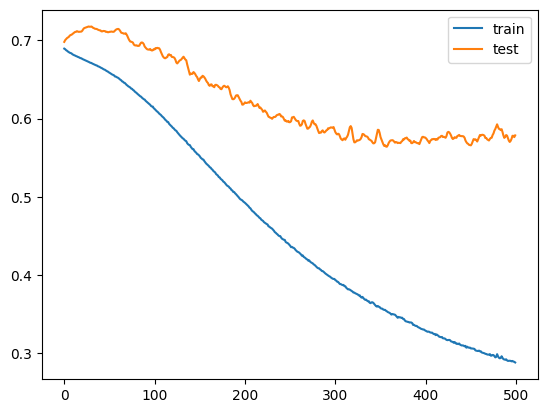

In [125]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 694us/step


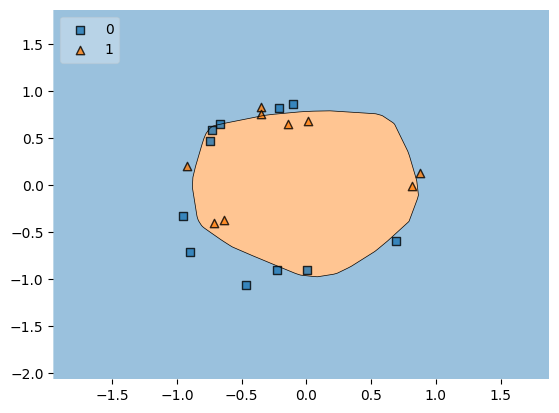

In [126]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()